In [39]:
import numpy as np
from pyscf import gto, scf, cc
import jax
jax.config.update("jax_enable_x64", True)

####  test H2 monomers ####
a = 2.4 # bond length in a cluster
d = 10 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
elmt = 'N'
unit = 'B'
basis = 'sto6g'
atoms = ''
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

stable = False
for i in range(10):
    print(f'mf stability test {i+1}')
    if not stable:
        mo_i, _, stable,_ = mf.stability(return_status=True)
        dm = mf.make_rdm1(mo_i,mf.mo_occ)
        mf.kernel(dm0=dm)
    elif stable:
        print(f'mf energy: {mf.e_tot}, stability {stable}')
        break

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

et = mycc.ccsd_t()
print(f"CCSD(T) Energy = {mycc.e_tot + et}")

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Aug  8 17:12:22 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 14
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit

In [40]:
from afqmc import prep_exp
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-6)


Preparing AFQMC calculation
CCSD type input object
Calculating Cholesky integrals
Cholesky shape: (44, 8, 8) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [5, 5]
Number of basis functions:  8
Number of Cholesky vectors: 44


In [42]:
import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'guide': 'rhf',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)
ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [43]:
print(sampler)
print(prop)

sampler(n_walkers=300, n_prop_steps=50, n_blocks=100, n_chol=44)
propagator_restricted(dt=0.005, n_walkers=300, n_exp_terms=6, n_batch=1)


In [44]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -108.50225+0.00000j        5.43
 5.00   300.37100    -108.72819       nan        8.66
10.00   299.43648    -108.70027       nan        9.05
15.00   299.00588    -108.69026       nan        9.45
20.00   299.42785    -108.71605       nan        9.85
25.00   299.44060    -108.69808       nan       10.24
30.00   298.99937    -108.69246       nan       10.64
35.00   300.66954    -108.79714       nan       11.04
40.00   299.07249    -108.70734       nan       11.43
45.00   299.35948    -108.72709       nan       11.83
50.00   299.31148    -108.70201       nan       12.23
55.00   298.77451    -108.67313       nan       12.62
60.00   299.90400    -108.74003       nan       13.02
65.00   298.76532    -108.67775       nan       13.42
70.00   299.51152    -108.69883       nan       13.81
75.00   299.54156    -108.71106       nan       14.21
80.00   298.92998    -108.66613       nan       14.61
85.00 

E = -108.712458 +/- 0.001905 Ha  (averaged over 421 blocks, t >= 20)


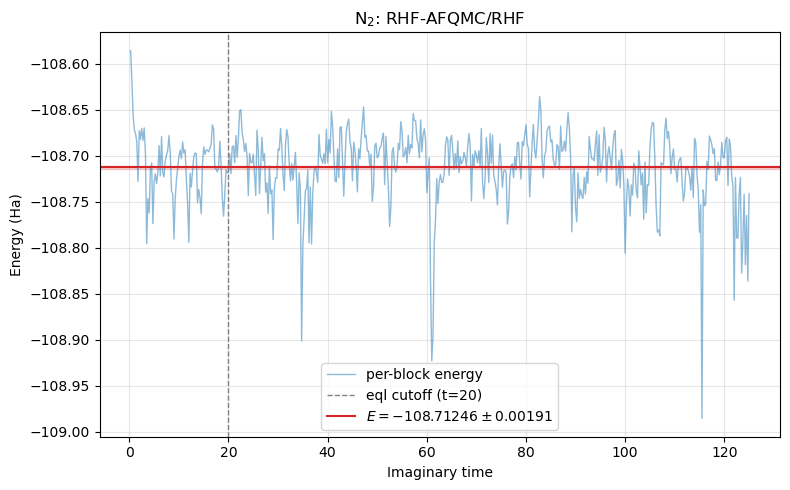

In [46]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: RHF-AFQMC/RHF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rhf',
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [48]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -108.50225+0.00000j        7.19
 5.00   264.48741    -108.70796       nan       11.69
10.00   268.76974    -108.68316       nan       12.33
15.00   264.23050    -108.71150       nan       12.96
20.00   263.56485    -108.71173       nan       13.59
25.00   263.42827    -108.71935       nan       14.22
30.00   264.33142    -108.70218       nan       14.84
35.00   264.61135    -108.71430       nan       15.47
40.00   266.22567    -108.69982       nan       16.10
45.00   262.27419    -108.72628       nan       16.73
50.00   265.93196    -108.69869       nan       17.35
55.00   264.66514    -108.70671       nan       17.98
60.00   266.87985    -108.68829       nan       18.61
65.00   269.48737    -108.67391       nan       19.23
70.00   262.26749    -108.71672       nan       19.86
75.00   263.22731    -108.72007       nan       20.49
80.00   268.93299    -108.67397       nan       21.11
85.00 

E = -108.712064 +/- 0.000896 Ha  (averaged over 421 blocks, t >= 20)


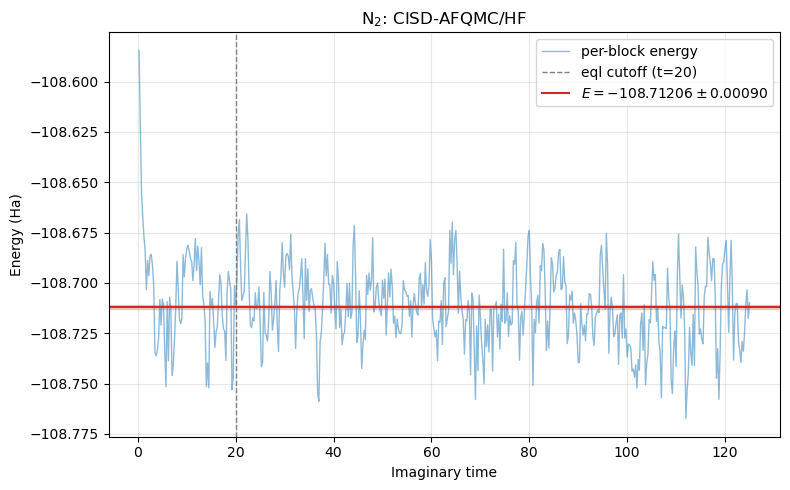

In [49]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rstoccsd',
            'trial': 'rhf',
            't2_thresh': 1e-3,
            'n_slater': 10,
            }

import time
import numpy as np
# from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep_exp, sampling_exp

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [53]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples, np.complex128)
en_sp = np.zeros(nsamples, np.complex128)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean
    en_sp[n] = energy_mean

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean.real:10.5f}  {energy_mean.real:12.5f}  {energy_err.real:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -108.50225+0.00000j        3.70
 5.00   265.95042    -108.70605       nan        9.77
10.00   262.81266    -108.70561       nan       12.72
15.00   261.12006    -108.70822       nan       15.67
20.00   262.56600    -108.71913       nan       18.63
25.00   266.58329    -108.68517       nan       21.59
30.00   268.37621    -108.68516       nan       24.54
35.00   258.34827    -108.72993       nan       27.49
40.00   262.01439    -108.69893       nan       30.45
45.00   263.15471    -108.72088       nan       33.40
50.00   257.47126    -108.71204       nan       36.35
55.00   262.21929    -108.72417       nan       39.30
60.00   257.80917    -108.72245       nan       42.25
65.00   266.90742    -108.67981       nan       45.20
70.00   260.10516    -108.73165       nan       48.16
75.00   264.63485    -108.70880       nan       51.11
80.00   264.31678    -108.67802       nan       54.06
85.00 

E = -108.711221 +/- 0.000878 Ha  (averaged over 421 blocks, t >= 20)


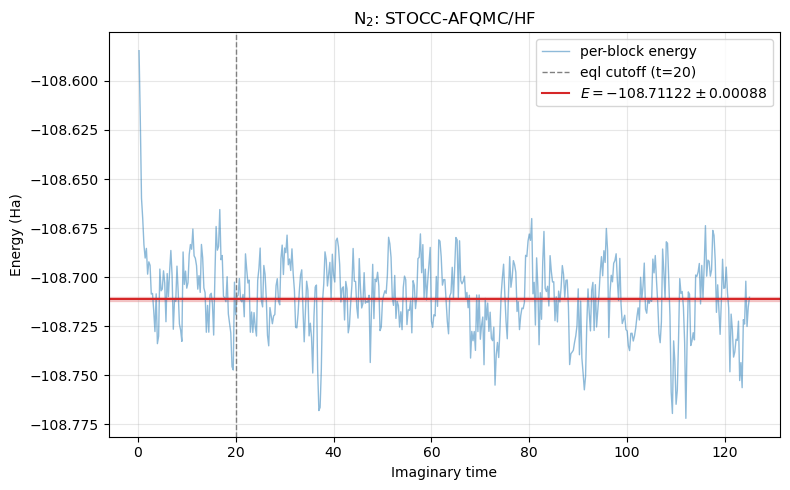

In [55]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: STOCC-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'guide': 'rcisd',
            'trial': 'rcisd',
            }

import time
import numpy as np
from afqmc import config

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

prep_exp.print_start()
config.setup_jax()

prop, wave, ham_data, wave_data, sampler, options = prep_exp.init_afqmc(options=options)

ham_data, wave_data = wave.build_intermediate(ham_data, wave_data)
ham_data = prop._build_propagation_intermediates(ham_data, wave, wave_data)
prop_data, init_w, init_e = prep_exp.init_prop_data(wave, wave_data, ham_data, options)
print(init_w, init_e)


    ________                     _____                    
    ___  __ \___  __________________(_)_____________ _    
    __  /_/ /  / / /_  __ \_  __ \_  /__  __ \_  __ `/    
    _  _, _// /_/ /_  / / /  / / /  / _  / / /  /_/ /     
    /_/ |_| \__,_/ /_/ /_//_/ /_//_/  /_/ /_/_\__, /      
                                             /____/       
    _____________________________  ___________            
    ___    |__  ____/_  __ \__   |/  /_  ____/            
    __  /| |_  /_   _  / / /_  /|_/ /_  /                 
    _  ___ |  __/   / /_/ /_  /  / / / /___               
    /_/  |_/_/      \___\_\/_/  /_/  \____/               

Hostname:     sharmagroup-rn
System:       Linux
Node:         sharmagroup-rn
Release:      7.0.0-28-generic
Machine:      x86_64
Processor:    x86_64
JAX backend:  GPU
JAX devices:  [CudaDevice(id=0)]
Device kind:  NVIDIA GeForce RTX 5060 Ti
Platform:     gpu

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers     

In [57]:
print("\nEquilibration")
print(f"{'1/T':>5s}  {'weight':>10s}  "
      f"{'energy':>12s}  {'error':>12s}  {'Time':>10s}")
print(f"{0.:5.2f}  {init_w:10.5f}  {init_e:12.5f}  "
      f"{time.time() - init_time:10.2f}")

block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
nsamples = 500

wt_sp = np.zeros(nsamples)
en_sp = np.zeros(nsamples)

for n in range(nsamples):
    prop_data, (weight, sample, _) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)

    weight_mean, energy_mean, energy_err \
            = wave.energy_formula(weight, sample, ham_data)
    wt_sp[n] = weight_mean.real
    en_sp[n] = energy_mean.real

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * energy_mean
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(nsamples // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  "
              f"{weight_mean:10.5f}  {energy_mean:12.5f}  {energy_err:8.5f}  "
              f"{time.time() - init_time:10.2f}")


Equilibration
  1/T      weight        energy         error        Time
 0.00  1.00000+0.00000j  -108.71051+0.00000j        1.33
 5.00  299.61625+0.00000j  -108.71450-0.00280j       nan        6.60
10.00  299.51786+0.00000j  -108.71571+0.00564j       nan        7.33
15.00  299.53559-0.00000j  -108.71319-0.00115j       nan        8.05
20.00  299.52934+0.00000j  -108.71404+0.00243j       nan        8.77
25.00  299.72914-0.00000j  -108.72843+0.00208j       nan        9.49
30.00  299.35233-0.00000j  -108.71260-0.00032j       nan       10.21
35.00  299.49790-0.00000j  -108.71905+0.00058j       nan       10.93
40.00  299.48007-0.00000j  -108.72166+0.00199j       nan       11.65
45.00  299.47746-0.00000j  -108.71337-0.00069j       nan       12.38
50.00  299.48234-0.00000j  -108.71653-0.00293j       nan       13.10
55.00  299.34058+0.00000j  -108.70842+0.00096j       nan       13.82
60.00  299.47332+0.00000j  -108.72283-0.00192j       nan       14.54
65.00  299.51815+0.00000j  -108.71033+0.00

E = -108.717754 +/- 0.000721 Ha  (averaged over 421 blocks, t >= 20)


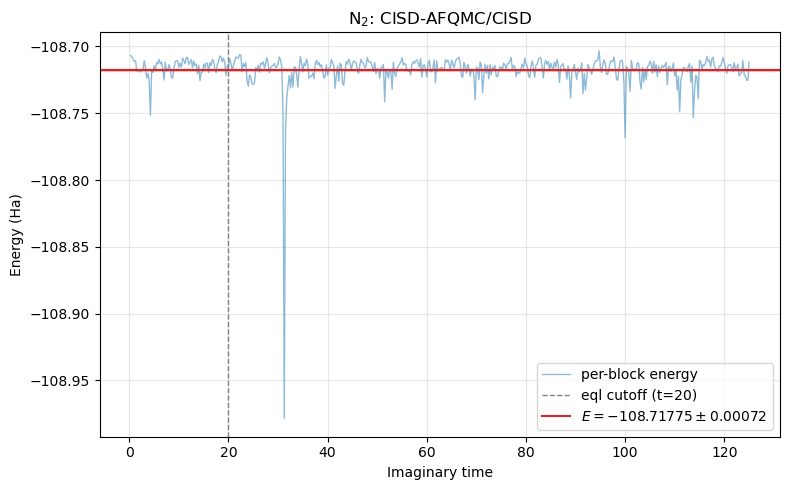

In [59]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, nsamples + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = wt_sp[mask].real
e = en_sp[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, en_sp.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("N$_2$: CISD-AFQMC/CISD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()